In [82]:
import pandas as pd
import sklearn.datasets as d
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

In [83]:
housing = d.fetch_california_housing(as_frame=True)
print(housing)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [84]:
x=pd.DataFrame(data=housing.data,columns=housing.feature_names)
x.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


In [85]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [86]:
y=pd.DataFrame(housing.target)
y.head(10)

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
5,2.697
6,2.992
7,2.414
8,2.267
9,2.611


In [87]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [88]:
model=LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
pred=model.predict(x_test)
print(pred)

[[0.71912284]
 [1.76401657]
 [2.70965883]
 ...
 [4.46877017]
 [1.18751119]
 [2.00940251]]


In [90]:
model.coef_

array([[ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,
         7.83144907e-01, -2.02962058e-06, -3.52631849e-03,
        -4.19792487e-01, -4.33708065e-01]])

In [91]:
r2_score(y_test,pred) * 100

57.57877060324512

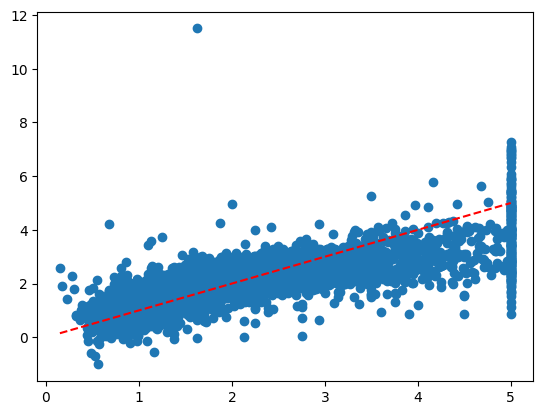

In [92]:
plt.scatter(y_test,pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')


In [95]:
result = permutation_importance(model, x, y, n_repeats=10, random_state=42)

importance = pd.Series(result.importances_mean, index=x.columns)
print(importance.sort_values(ascending=False))

Latitude      1.216196
Longitude     1.136543
MedInc        1.086363
AveBedrms     0.189332
AveRooms      0.149680
HouseAge      0.022347
AveOccup      0.002090
Population    0.000010
dtype: float64


In [96]:
x.drop(["HouseAge","AveOccup","Population"],axis=1,inplace=True)
x.head(10)

,MedInc,AveRooms,AveBedrms,Latitude,Longitude
0,8.3252,6.984127,1.023810,37.88,-122.23
1,8.3014,6.238137,0.971880,37.86,-122.22
2,7.2574,8.288136,1.073446,37.85,-122.24
3,5.6431,5.817352,1.073059,37.85,-122.25
4,3.8462,6.281853,1.081081,37.85,-122.25
5,4.0368,4.761658,1.103627,37.85,-122.25
6,3.6591,4.931907,0.951362,37.84,-122.25
7,3.1200,4.797527,1.061824,37.84,-122.25
8,2.0804,4.294118,1.117647,37.84,-122.26
9,3.6912,4.970588,0.990196,37.84,-122.25


In [100]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

new_model=LinearRegression()
new_model.fit(x_train,y_train)

In [102]:
new_pred=new_model.predict(x_test)
print(new_pred)

[[0.74141747]
 [1.78095929]
 [2.52942871]
 ...
 [4.48376897]
 [1.08874619]
 [2.13331461]]


In [103]:
r2_score(y_test,new_pred) * 100

56.74865431409175